# QRC with PCA

In [242]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

import torch
import torch.nn as nn

# MerLin (adjust imports to your installed version)
from merlin import CircuitBuilder, QuantumLayer
#from merlin.grouping import LexGrouping
from merlin.measurement import MeasurementStrategy
#from merlin.computation_space import ComputationSpace 

In [243]:
from datasets import load_dataset
import pandas as pd

ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)

ds_level2 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-2_Missing_data_prediction/train_level2.csv",
    split="train",
)

df1 = ds_level1.to_pandas()
df2 = ds_level2.to_pandas()

print("Level 1 shape:", df1.shape)
print("Level 2 shape:", df2.shape)

print("\nFirst columns:", df1.columns[:5])
print("\nTop missing columns:")
print(df2.isna().mean().sort_values(ascending=False).head(10))

Level 1 shape: (494, 225)
Level 2 shape: (489, 225)

First columns: Index(['Date', 'Tenor : 1; Maturity : 0.0833333333333333',
       'Tenor : 2; Maturity : 0.0833333333333333',
       'Tenor : 3; Maturity : 0.0833333333333333',
       'Tenor : 4; Maturity : 0.0833333333333333'],
      dtype='str')

Top missing columns:
Date                        0.0
Tenor : 1; Maturity : 4     0.0
Tenor : 3; Maturity : 7     0.0
Tenor : 4; Maturity : 7     0.0
Tenor : 5; Maturity : 7     0.0
Tenor : 6; Maturity : 7     0.0
Tenor : 7; Maturity : 7     0.0
Tenor : 8; Maturity : 7     0.0
Tenor : 9; Maturity : 7     0.0
Tenor : 10; Maturity : 7    0.0
dtype: float64


In [244]:
import re

print("Total columns:", len(df1.columns))
print(df1.columns[:20].tolist())

# show any columns containing "Price"
price_like = [c for c in df1.columns if "Price" in str(c)]
print("Price-like examples:", price_like[:20])

Total columns: 225
['Date', 'Tenor : 1; Maturity : 0.0833333333333333', 'Tenor : 2; Maturity : 0.0833333333333333', 'Tenor : 3; Maturity : 0.0833333333333333', 'Tenor : 4; Maturity : 0.0833333333333333', 'Tenor : 5; Maturity : 0.0833333333333333', 'Tenor : 6; Maturity : 0.0833333333333333', 'Tenor : 7; Maturity : 0.0833333333333333', 'Tenor : 8; Maturity : 0.0833333333333333', 'Tenor : 9; Maturity : 0.0833333333333333', 'Tenor : 10; Maturity : 0.0833333333333333', 'Tenor : 15; Maturity : 0.0833333333333333', 'Tenor : 20; Maturity : 0.0833333333333333', 'Tenor : 25; Maturity : 0.0833333333333333', 'Tenor : 30; Maturity : 0.0833333333333333', 'Tenor : 1; Maturity : 0.25', 'Tenor : 2; Maturity : 0.25', 'Tenor : 3; Maturity : 0.25', 'Tenor : 4; Maturity : 0.25', 'Tenor : 5; Maturity : 0.25']
Price-like examples: []


In [245]:
df1["Date"] = pd.to_datetime(df1["Date"], dayfirst=True)
df1 = df1.sort_values("Date")

In [246]:
#Let's try visualizing the 'Price' column over time first to see how it looks like
import matplotlib.pyplot as plt
import numpy as np
import re

surface_cols = [col for col in df1.columns if col != "Date"]

tenors = []
marturities = []

for col in surface_cols:
    t = float(re.search(r"Tenor : (.*?);", col).group(1))
    m = float(re.search(r"Maturity : (.*)", col).group(1))
    tenors.append(t)
    marturities.append(m)

tenors = np.array(tenors)
marturities = np.array(marturities)

In [247]:
#Build the surface matrix 
S = df1[surface_cols].astype(float).to_numpy()
print(S.shape)

(494, 224)


In [248]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------
# 0) Start from surfaces
# -------------------------
# S: shape (T, n_surface_points)
# e.g. S = df1[surface_cols].to_numpy().astype("float32")

T = S.shape[0]
split_t = int(0.8 * T)

S_train, S_test = S[:split_t], S[split_t:]

# -------------------------
# 1) Scale + PCA on surfaces (fit on train only)
# -------------------------
surf_scaler = StandardScaler()
S_train_scaled = surf_scaler.fit_transform(S_train)
S_test_scaled  = surf_scaler.transform(S_test)

d = 12  # latent surface dimension (try 6, 8, 12)
pca = PCA(n_components=d, random_state=0)
Z_train = pca.fit_transform(S_train_scaled)   # (T_train, d)
Z_test  = pca.transform(S_test_scaled)        # (T_test,  d)

# -------------------------
# 2) Build lagged dataset in PCA space
# -------------------------
k = 3  # lag length

X_train, Y_train = [], []
for t in range(k, len(Z_train)):
    X_train.append(Z_train[t-k:t].reshape(-1))   # (k*d,)
    Y_train.append(Z_train[t])                  # (d,)

X_test, Y_test = [], []
for t in range(k, len(Z_test)):
    X_test.append(Z_test[t-k:t].reshape(-1))
    Y_test.append(Z_test[t])

X_train = np.asarray(X_train, dtype="float32")
Y_train = np.asarray(Y_train, dtype="float32")
X_test  = np.asarray(X_test,  dtype="float32")
Y_test  = np.asarray(Y_test,  dtype="float32")

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

# Optional: clip inputs for angle encoding stability
# X_train = np.clip(X_train, -2, 2)
# X_test  = np.clip(X_test,  -2, 2)    # X dim should be ~ (N, 24) if k=3,d=8

X_train: (392, 36) Y_train: (392, 12)
X_test : (96, 36) Y_test : (96, 12)


In [249]:
print(np.min(X))

-25.802917


In [250]:
#Train of test the split by time
#split = int(0.8 * len(X))
#X_train, X_test = X[:split], X[split:]
#Y_train, Y_test = Y[:split], Y[split:]

In [251]:
'''
#Build Merlin reservoir
torch.manual_seed(0)

n_modes = 8
n_photons = 2   # small for tractability (Fock reservoir)
dtype = torch.float64

builder = CircuitBuilder(n_modes = n_modes)
# Add random linear layers (interferometers)
builder.add_entangling_layer(trainable= False, name="U_res")
#The goal is to get a real_valued output, so we measure the photon number in each mode
measurement = MeasurementStrategy.probs()
quantum_layer = QuantumLayer(builder = builder, measurement_strategy = measurement, n_photons = n_photons, dtype = dtype, amplitude_encoding=True)
input_size = quantum_layer.input_size

class AmplitudePadAndNormalize(nn.Module):
    """Pad k*d real features to match amplitude dim, then L2-normalize."""
    def __init__(self, target_dim: int):
        super().__init__()
        self.target_dim = target_dim

    def forward(self, x_real: torch.Tensor) -> torch.Tensor:
        # x_real: (batch, k*d) float
        x = torch.zeros((x_real.shape[0], self.target_dim), dtype=torch.complex64, device=x_real.device)
        n = min(x_real.shape[1], self.target_dim)
        x[:, :n] = x_real[:, :n].to(torch.complex64)

        # L2 normalization for amplitude encoding
        norm = torch.linalg.norm(x, dim=1, keepdim=True) + 1e-12
        x = x / norm
        return x
padder = AmplitudePadAndNormalize(input_size)
def quantum_features(X_np, batch_size: int = 128):
    #Run the Merlin layer and return features as numpy array
    quantum_layer.eval()
    features = []

    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32)
            amplitude = padder(xb)
            out = quantum_layer(amplitude)

            # If out is complex or dict-like, adapt like this:
            if isinstance(out, dict):
                # e.g. out["features"] or out["probs"]
                out = out.get("features", next(iter(out.values())))
            if torch.is_complex(out):
                out = torch.view_as_real(out).reshape(out.shape[0], -1)

            features.append(out.cpu().numpy())
    return np.concatenate(features, axis=0)
#Extract quantum features for train and test sets from reservoir
Phi_train = quantum_features(X_train)
Phi_test = quantum_features(X_test)

print("Phi_train shape:", Phi_train.shape)
print('Reservoir features dim', Phi_train.shape[1])
readout = Ridge(alpha=0.01)
readout.fit(Phi_train, Y_train)

C_predicted = readout.predict(Phi_test)
#Reconstruct the predicted surface from PCA space

S_predicted_scale = pca.inverse_transform(C_predicted) # back to scaled surface
S_predicted = scaler.inverse_transform(S_predicted_scale)  # back to original units


idx = 0
true_surface = S[split + k + idx]
pred_surface = S_predicted[idx]

print('True surface:', true_surface)
print('Predicted surface:', pred_surface)
'''

'\n#Build Merlin reservoir\ntorch.manual_seed(0)\n\nn_modes = 8\nn_photons = 2   # small for tractability (Fock reservoir)\ndtype = torch.float64\n\nbuilder = CircuitBuilder(n_modes = n_modes)\n# Add random linear layers (interferometers)\nbuilder.add_entangling_layer(trainable= False, name="U_res")\n#The goal is to get a real_valued output, so we measure the photon number in each mode\nmeasurement = MeasurementStrategy.probs()\nquantum_layer = QuantumLayer(builder = builder, measurement_strategy = measurement, n_photons = n_photons, dtype = dtype, amplitude_encoding=True)\ninput_size = quantum_layer.input_size\n\nclass AmplitudePadAndNormalize(nn.Module):\n    """Pad k*d real features to match amplitude dim, then L2-normalize."""\n    def __init__(self, target_dim: int):\n        super().__init__()\n        self.target_dim = target_dim\n\n    def forward(self, x_real: torch.Tensor) -> torch.Tensor:\n        # x_real: (batch, k*d) float\n        x = torch.zeros((x_real.shape[0], self.t

In [252]:
import matplotlib.tri as mtri
from merlin import CircuitBuilder, QuantumLayer
from merlin.measurement import MeasurementStrategy

# Now I follow the rule: No state injection and no amplitude encoding. So I do the angle isplacement encoding.

In [253]:
from merlin.builder import CircuitBuilder
import inspect
import torch
import torch.nn as nn

builder = CircuitBuilder(n_modes=6)
print([m for m in dir(builder) if m.startswith("add_")])

['add_angle_encoding', 'add_entangling_layer', 'add_rotations', 'add_superpositions']


In [254]:
import perceval as pcvl
"""
n_modes = 12
n_photons = 8

input_state = pcvl.BasicState([1]*n_photons + [0]*(n_modes - n_photons))
print(input_state)
"""

'\nn_modes = 12\nn_photons = 8\n\ninput_state = pcvl.BasicState([1]*n_photons + [0]*(n_modes - n_photons))\nprint(input_state)\n'

In [255]:
def x_to_angles(x_real: torch.Tensor) -> torch.Tensor:
    # x: (batch, kd)
    #x_real = x_real.to(torch.float32)
    u = x_real@A
    u = torch.tanh(u)
    angles = u * angle_scale
    return angles


def random_mix(X, seed):
    rng = np.random.RandomState(seed)
    W = rng.normal(size=(X.shape[1], X.shape[1]))
    Q, _ = np.linalg.qr(W)          # orthonormal for stability
    return X @ Q

In [256]:
[m for m in dir(builder) if any(k in m.lower() for k in ["phase", "ps", "rotation", "angle", "bs", "beam", "mzi"])]

['_angle_encoding_counts',
 '_angle_encoding_scales',
 '_angle_encoding_specs',
 '_normalize_angle_scale',
 'add_angle_encoding',
 'add_rotations',
 'angle_encoding_specs']

In [257]:
kd = X_train.shape[1]
p = kd

A = torch.randn((p, p), dtype=torch.float32)/np.sqrt(p)
A.requires_grad_(False)

angle_scale = np.pi


In [258]:
import numpy as np
import torch

from merlin import CircuitBuilder, QuantumLayer
from merlin.measurement import MeasurementStrategy
from merlin.core.state_vector import StateVector 

In [297]:
n_modes = 12  # keep small
n_photons = 2

builder = CircuitBuilder(n_modes=n_modes)

# Important: encoding must be present
builder.add_angle_encoding(name="ENC1", scale=np.pi)   # or 2*np.pi
builder.add_entangling_layer(trainable=False, name="U1")
builder.add_rotations(trainable=False, name="R1")
#builder.add_angle_encoding(name="ENC2", scale=2*np.pi)
#builder.add_entangling_layer(trainable=False, name="U2")

quantum_layer = QuantumLayer(
    builder=builder,
    n_photons=n_photons,
    amplitude_encoding=False,
    measurement_strategy=MeasurementStrategy.probs(),
    dtype=torch.float32,
)

In [298]:
print("input_parameter_prefixes:", builder.input_parameter_prefixes)

input_parameter_prefixes: ['ENC']


In [299]:
def make_reservoir_layer_with_phases(
    seed: int,
    n_modes: int,
    n_photons: int,
    dtype=torch.float32,
    enc_scale=np.pi,
):
    rng = np.random.RandomState(seed)

    builder = CircuitBuilder(n_modes=n_modes)

    # (1) Encode data (rule-compliant: no amplitude encoding)
    builder.add_angle_encoding(name="ENC", scale=enc_scale)

    # (2) Reservoir-specific phase mask (fixed)
    phases = rng.uniform(0, 2*np.pi, size=n_modes)

    # Try common API variants:
    if hasattr(builder, "add_phase_shifts"):
        try:
            builder.add_phase_shifts(values=phases, trainable=False, name=f"PHASE_{seed}")
        except TypeError:
            # some versions might use "phase_shifts" instead of "values"
            builder.add_phase_shifts(phase_shifts=phases, trainable=False, name=f"PHASE_{seed}")
    else:
        raise AttributeError("The CircuitBuilder has no method add_phase_shifts().")

    # (3) Fixed reservoir dynamics
    builder.add_rotations(trainable=False, name="R1")
    builder.add_entangling_layer(trainable=False, name="U_res")

    measurement = MeasurementStrategy.probs()
    qlayer = QuantumLayer(
        builder=builder,
        measurement_strategy=measurement,
        n_photons=n_photons,
        dtype=dtype,
        amplitude_encoding=False,
    )
    return qlayer

In [300]:
def build_phi(X_matrix):
    Phi = []
    for x in X_matrix:
        features = run_quantum_circuit(x)
        Phi.append(features)
    return np.array(Phi)
def perm_sign_mix(X, seed):
    rng = np.random.RandomState(seed)
    perm = rng.permutation(X.shape[1])
    signs = rng.choice([-1.0, 1.0], size=X.shape[1])
    return X[:, perm] * signs
def compute_phi(quantum_layer, X_np: np.ndarray, batch_size: int = 64) -> np.ndarray:
    """
    X_np: (N, d) numpy array (float)
    returns: Phi: (N, Dphi) numpy array
    """
    quantum_layer.eval()
    Phi_chunks = []

    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=quantum_layer.dtype)
            out = quantum_layer(xb)          # torch.Tensor, shape (B, Dphi) typically
            Phi_chunks.append(out.detach().cpu().numpy())

    return np.vstack(Phi_chunks)

Phi_train = compute_phi(quantum_layer, X_train, batch_size=64)
Phi_test  = compute_phi(quantum_layer, X_test,  batch_size=64)

print("Phi_train:", Phi_train.shape)
print("Phi_test :", Phi_test.shape)

Phi_train: (392, 66)
Phi_test : (96, 66)


In [301]:
R = 5
seeds = list(range(R))

Phi_train_list, Phi_test_list = [], []
for s in range(R):
    Xtr_r = perm_sign_mix(X_train, s)
    Xte_r = perm_sign_mix(X_test,  s)

    Phi_train_list.append(compute_phi(quantum_layer, Xtr_r, batch_size=64))
    Phi_test_list.append(compute_phi(quantum_layer, Xte_r, batch_size=64))
    print("seed", s,
      "X diff max:", np.max(np.abs(Xtr_r - X_train)),
      "X diff mean:", np.mean(np.abs(Xtr_r - X_train)))

Phi_train_multi = np.hstack(Phi_train_list)
Phi_test_multi  = np.hstack(Phi_test_list)

print("Phi_train_multi:", Phi_train_multi.shape)
print("Phi_test_multi :", Phi_test_multi.shape)

seed 0 X diff max: 38.420132994651794 X diff mean: 3.0050452295214183
seed 1 X diff max: 68.40436172485352 X diff mean: 3.116962314895152
seed 2 X diff max: 68.40436172485352 X diff mean: 3.2235433398599986
seed 3 X diff max: 37.94137370586395 X diff mean: 2.830490419162454
seed 4 X diff max: 38.420132994651794 X diff mean: 2.989571972151683
Phi_train_multi: (392, 330)
Phi_test_multi : (96, 330)


In [302]:
readout = Ridge(alpha=0.000001).fit(Phi_train, Y_train)
Yhat_test = readout.predict(Phi_test)   # shape (N_test, d)

In [303]:
# Yhat_test: predicted Z for next step, shape (N_test, d)
Z_pred = Yhat_test
             # (N_test, d)
S_scaled_pred = pca.inverse_transform(Z_pred)
S_pred = x_scaler.inverse_transform(S_scaled_pred)  
S_scaled_pred = pca.inverse_transform(Yhat_test)          # (N_test, n_surface_points)
S_pred = surf_scaler.inverse_transform(S_scaled_pred)     # back to original scale

# Align true surfaces inside test block:
# For each Y_test sample t, it corresponds to Z_test[t], which corresponds to S_test[t] (same index)
S_true = S_test[k:]                                       # (N_test, n_surface_points)

rmse = np.sqrt(np.mean((S_true - S_pred)**2))
mae  = np.mean(np.abs(S_true - S_pred))
print("Surface RMSE:", rmse, "Surface MAE:", mae)

Surface RMSE: 0.018185452713021126 Surface MAE: 0.014202092644606003


In [304]:
print("X_train:", X_train.shape, "y_train_s:", Y_train.shape)
print("Phi_train:", Phi_train.shape)
assert Phi_train.shape[0] == Y_train.shape[0]
assert Phi_test.shape[0]  == Y_test.shape[0]

X_train: (392, 36) y_train_s: (392, 12)
Phi_train: (392, 66)


In [305]:
print("angle specs:", builder.angle_encoding_specs)
print("counts:", getattr(builder, "_angle_encoding_counts", None))
print("scales:", getattr(builder, "_angle_encoding_scales", None))

angle specs: {'ENC1': {'combinations': [(0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (8,), (9,), (10,), (11,)], 'scales': {0: 3.141592653589793, 1: 3.141592653589793, 2: 3.141592653589793, 3: 3.141592653589793, 4: 3.141592653589793, 5: 3.141592653589793, 6: 3.141592653589793, 7: 3.141592653589793, 8: 3.141592653589793, 9: 3.141592653589793, 10: 3.141592653589793, 11: 3.141592653589793}}}
counts: {'ENC1': 12}
scales: {'ENC1': {0: 3.141592653589793, 1: 3.141592653589793, 2: 3.141592653589793, 3: 3.141592653589793, 4: 3.141592653589793, 5: 3.141592653589793, 6: 3.141592653589793, 7: 3.141592653589793, 8: 3.141592653589793, 9: 3.141592653589793, 10: 3.141592653589793, 11: 3.141592653589793}}


In [306]:
tri = mtri.Triangulation(tenors, marturities)

def plot_surface(z, title, label="Vol", levels=30, vmin=None, vmax=None):
    plt.figure(figsize=(7, 5))
    cf = plt.tricontourf(tri, z, levels=levels, vmin=vmin, vmax=vmax)
    plt.colorbar(cf, label=label)
    plt.xlabel("Tenor")
    plt.ylabel("Maturity")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [307]:
print("tri points:", len(tri.x), len(tri.y))
print("true_surface:", true_surface.shape)
print("pred_surface:", pred_surface.shape)

tri points: 224 224
true_surface: (224,)
pred_surface: (224,)


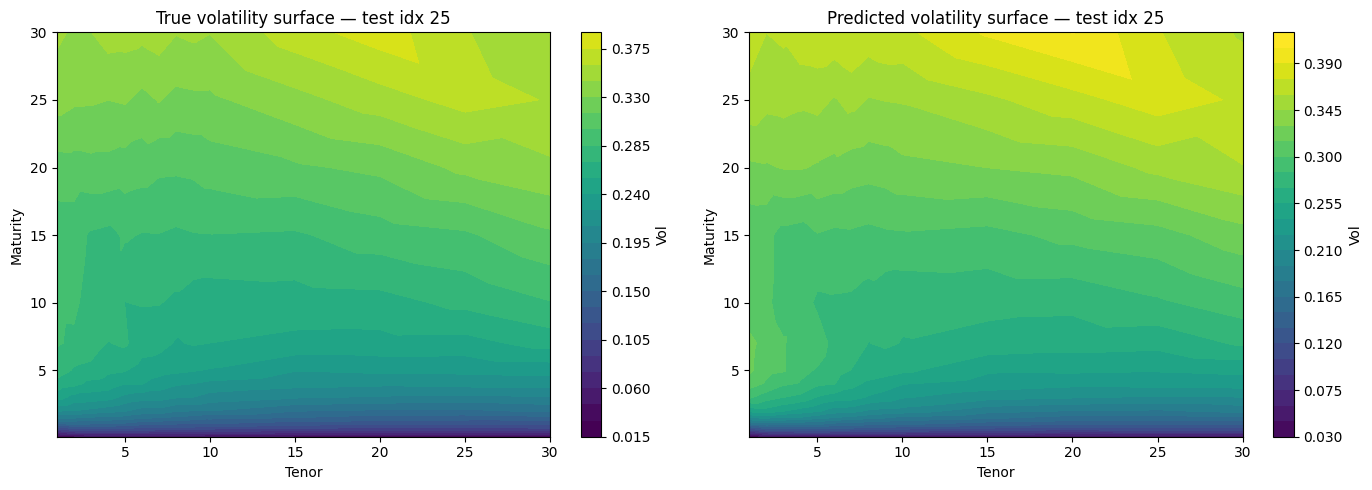

In [308]:
j = 25  # I pick any test sample index


true_surface = S[j]          # already aligned Y_test
pred_surface = S_pred[j]            # your inverse-transformed prediction

vmin = min(true_surface.min(), pred_surface.min())
vmax = max(true_surface.max(), pred_surface.max())

vmin = min(true_surface.min(), pred_surface.min())
vmax = max(true_surface.max(), pred_surface.max())

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cf1 = plt.tricontourf(tri, true_surface, levels=30, vmin=vmin, vmax=vmax)
plt.colorbar(cf1, label="Vol")
plt.xlabel("Tenor")
plt.ylabel("Maturity")
plt.title(f"True volatility surface — test idx {j}")

plt.subplot(1, 2, 2)
cf2 = plt.tricontourf(tri, pred_surface, levels=30, vmin=vmin, vmax=vmax)
plt.colorbar(cf2, label="Vol")
plt.xlabel("Tenor")
plt.ylabel("Maturity")
plt.title(f"Predicted volatility surface — test idx {j}")

plt.tight_layout()
plt.show()

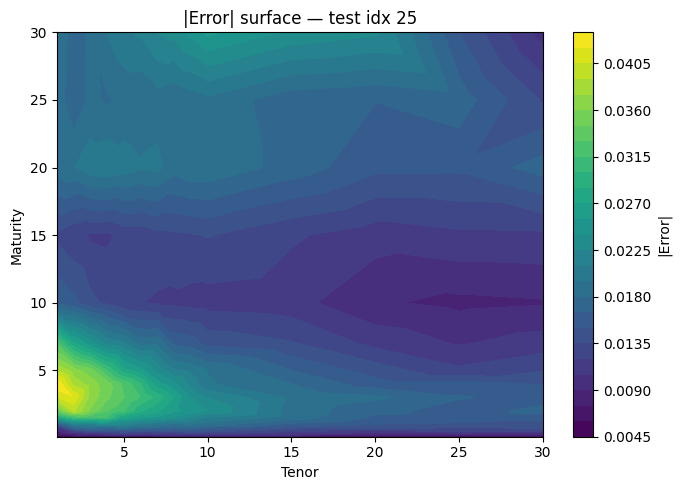

In [309]:
err = np.abs(pred_surface - true_surface)
plot_surface(err, f"|Error| surface — test idx {j}", label="|Error|")

In [310]:
print("Y_test_ori min/max:", Y_test_ori.min(), Y_test_ori.max())
print("Y_test_ori std (global):", Y_test_ori.std())

Y_test_ori min/max: 0.0204977440771758 0.416984696494861
Y_test_ori std (global): 0.0950815157136535


In [311]:
eps = 1e-6
rel_rmse = np.sqrt(np.mean(((S[1] - S_pred[1]) / (S + eps))**2))
print("Relative RMSE:", rel_rmse)

Relative RMSE: 0.1351992637457976


In [312]:
print("mean:", np.mean(S_pred))
print("std :", np.std(S_pred))
print("min :", np.min(S_pred))
print("max :", np.max(S_pred))

mean: 0.22569238824621396
std : 0.09850947655176145
min : 0.03140274908016491
max : 0.40554548723843437


In [313]:
j = 0
t = split + j + k
print("test idx j =", j)
print("corresponding original time index t =", t)
print("corresponding date =", df1.iloc[t]["Date"])


test idx j = 0
corresponding original time index t = 395
corresponding date = 2051-08-01 00:00:00


In [314]:
# In PCA space:
Yhat_persist = X_test[:, -d:]  # last Z in the lag window
rmse_persist = np.sqrt(np.mean((Y_test - Yhat_persist)**2))
print("Persistence RMSE (PCA space):", rmse_persist)

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1e-2).fit(X_train, Y_train)
Yhat_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(np.mean((Y_test - Yhat_ridge)**2))
print("Ridge RMSE (PCA space):", rmse_ridge)

Persistence RMSE (PCA space): 0.7832438
Ridge RMSE (PCA space): 0.8357096


/Users/alexquach/Desktop/merlin/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.914172618304292e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [315]:
S_scaled_pred = pca.inverse_transform(Yhat_test)
S_pred = surf_scaler.inverse_transform(S_scaled_pred)
S_true = S_test[k:]

rmse_surface = np.sqrt(np.mean((S_true - S_pred)**2))
mae_surface  = np.mean(np.abs(S_true - S_pred))
print("Surface RMSE:", rmse_surface)
print("Surface MAE :", mae_surface)

eps = 1e-8
mape = np.mean(np.abs(S_true - S_pred) / (np.abs(S_true) + eps))
print("Surface relative error (MAPE-like):", mape)

Surface RMSE: 0.018185452713021126
Surface MAE : 0.014202092644606003
Surface relative error (MAPE-like): 0.08240591787933137


In [316]:
rmse_qrc = np.sqrt(np.mean((Y_test - Yhat_test)**2))
print("QRC RMSE (PCA space):", rmse_qrc)

QRC RMSE (PCA space): 4.0654783


In [317]:
Phi_train = compute_phi(quantum_layer, X_train, batch_size=64)
Phi_test  = compute_phi(quantum_layer, X_test,  batch_size=64)

print("Phi_train shape:", Phi_train.shape, "Phi_test shape:", Phi_test.shape)
print("Phi_train stats: min/mean/max =", Phi_train.min(), Phi_train.mean(), Phi_train.max())
print("Phi_train std (median):", np.median(Phi_train.std(axis=0)))
print("NaN/Inf in Phi_train?", np.isnan(Phi_train).any(), np.isinf(Phi_train).any())

Phi_train shape: (392, 66) Phi_test shape: (96, 66)
Phi_train stats: min/mean/max = 0.0 0.015151516 1.0
Phi_train std (median): 0.0
NaN/Inf in Phi_train? False False


In [318]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(Y_test_ori, Y_pred))
mae  = mean_absolute_error(Y_test_ori, Y_pred)
print("MAE, RMSE (original units):", mae, rmse)

NameError: name 'Y_pred' is not defined

In [ ]:
print("Phi_train", Phi_train.shape)
print("Y_train", Y_train.shape)

Phi_train (392, 28)
Y_train (392, 12)


In [ ]:
yhat = np.full_like(Y_test, Y_train.mean())
rmse = np.sqrt(np.mean((Y_test - yhat)**2))
print("Mean baseline RMSE:", rmse)

from sklearn.linear_model import Ridge
m = Ridge(alpha=1.0).fit(X_train, Y_train)
yhat = m.predict(X_test)
rmse = np.sqrt(np.mean((Y_test-yhat)**2))
print("Ridge-on-X RMSE:", rmse)

Mean baseline RMSE: 0.9642707209038157
Ridge-on-X RMSE: 0.3456838887382458


In [ ]:
feat_std = Phi_train.std(axis=0)
print("Phi_train feature std: min/median/max =",
      feat_std.min(), np.median(feat_std), feat_std.max())
print("Fraction near-constant (std < 1e-6):", np.mean(feat_std < 1e-6))

Phi_train feature std: min/median/max = 0.028239234956639332 0.03686181556876187 0.05505889074700971
Fraction near-constant (std < 1e-6): 0.0
